In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import igraph as ig
import leidenalg
from sklearn.metrics import adjusted_rand_score

In [25]:
BASE_DIR         = Path("/Users/bgadmin/Downloads/multiomics_preproc")
KNN_BY_GROUP_DIR  = BASE_DIR / "knn_index" / "knn_by_cancer_group"
KNN_PERGROUP_BEST = KNN_BY_GROUP_DIR / "pergroup_best"
OUT_DIR          = BASE_DIR / "clustering_leiden"

OUT_DIR.mkdir(parents=True, exist_ok=True)

MOFA_FACTORS_PATH = BASE_DIR / "mofa_factors.parquet"
META_PATH         = BASE_DIR / "meta_final.tsv"
MANIFEST_PATH     = KNN_PERGROUP_BEST / "knn_manifest.tsv"

ID_COL    = "biosample_id"
LABEL_COL = "cancer_group"

# Leiden Parameters
SEEDS          = [0, 1, 2, 3, 4]   
MIN_CLUSTER_SIZE = 50  

In [26]:
meta = pd.read_csv(BASE_DIR / "meta_final.tsv", sep="\t", dtype=str)
print(meta["cancer_group"].value_counts())

cancer_group
Lung (C30-C39)                           1302
Gynecologic (C51-C58)                    1135
Urinary (C64-C68)                        1110
Breast (C50)                              969
Brain (C71)                               737
Thyroid/Endocrine (C73-C75)               719
Male genital (C60-C63)                    617
Colorectal (C18-C20)                      565
C16                                       406
Liver/Biliary (C22-C24)                   398
Head & Neck (C00_C14)                     379
Lymph nodes (C77)                         237
SoftTissue (C49)                          196
Esophagus/Intestine (C15-C17-C21-C26)     193
C25                                       165
Skin (C44)                                149
Bone/SoftTissue (C40-C48)                 113
Blood/Lymph (C42)                         107
Eye/CNS (C69-C72)                          85
C76                                         8
C80                                         1
C47                  

### Load

In [27]:
Z_mofa_df = pd.read_parquet(MOFA_FACTORS_PATH)
Z_mofa_df.index = Z_mofa_df.index.astype(str)

meta = pd.read_csv(META_PATH, sep="\t", dtype=str)
meta[ID_COL] = meta[ID_COL].astype(str)

# Manifest
manifest = pd.read_csv(MANIFEST_PATH, sep="\t", dtype=str)
manifest["n_samples"] = manifest["n_samples"].astype(int)
manifest["K"]         = manifest["K"].astype(int)

print(f"MOFA factors : {Z_mofa_df.shape[0]:,} samples x {Z_mofa_df.shape[1]} factors")
print(f"Metadata     : {meta.shape[0]:,} samples")
print(f"Cancer groups to analyze : {len(manifest)}")
print(manifest[["cancer_group", "n_samples", "K"]].to_string(index=False))

MOFA factors : 9,592 samples x 20 factors
Metadata     : 9,592 samples
Cancer groups to analyze : 19
                         cancer_group  n_samples  K
                    Blood/Lymph (C42)        107 50
            Bone/SoftTissue (C40-C48)        113 50
                          Brain (C71)        737 50
                         Breast (C50)        969 50
                                  C16        406 50
                                  C25        165 50
                 Colorectal (C18-C20)        565 50
Esophagus/Intestine (C15-C17-C21-C26)        193 50
                    Eye/CNS (C69-C72)         85 50
                Gynecologic (C51-C58)       1135 50
                Head & Neck (C00_C14)        379 50
              Liver/Biliary (C22-C24)        398 50
                       Lung (C30-C39)       1302 50
                    Lymph nodes (C77)        237 50
               Male genital (C60-C63)        617 50
                           Skin (C44)        149 50
               

### Construction of the graph :
- tranfomation distance -> poids


In [28]:
def w_inv1p(d: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    # Inverse of (1 + distance) — always between 0 and 1
    return 1.0 / (1.0 + np.maximum(d, eps))

def w_rbf(d: np.ndarray, sigma: float, eps: float = 1e-6) -> np.ndarray:
    ''' exp(-d²/2σ²) — Gaussian decay
        sigma controls the rate of decay
        small sigma → weights decrease rapidly with distance
        large sigma → weights remain high even at great distances
        '''
    d = np.maximum(d, eps)
    return np.exp(-(d * d) / (2.0 * sigma * sigma))

def w_exp(d: np.ndarray, scale: float, eps: float = 1e-6) -> np.ndarray:
    # exp(-d/scale) — exponential decay    d = np.maximum(d, eps)
    return np.exp(-(d) / scale)

def _summ(x: np.ndarray) -> dict:
    # Descriptive statistics on an array
    # Used to compare the dispersion of weights
    x = np.asarray(x).ravel()
    x = x[np.isfinite(x)]
    if x.size == 0:
        return {"min": np.nan, "p10": np.nan, "median": np.nan,
                "p90": np.nan, "max": np.nan}
    return {
        "min":    float(np.min(x)),
        "p10":    float(np.quantile(x, 0.10)),
        "median": float(np.median(x)),
        "p90":    float(np.quantile(x, 0.90)),
        "max":    float(np.max(x)),
    }

In [29]:
#evaluate the diffirents transformation 
#the one with the higher dispersion is the better one

rows_weights = []

for _, row in manifest.iterrows():
    cancer_group = row["cancer_group"]

    # Load the distances oh the group
    dist_path = KNN_PERGROUP_BEST / row["knn_dist_file"]
    ids_df    = pd.read_parquet(KNN_PERGROUP_BEST / row["knn_idx_file"])
    dists_df  = pd.read_parquet(KNN_PERGROUP_BEST / row["knn_dist_file"])
    d_cols    = [c for c in dists_df.columns if c != ID_COL]
    d         = dists_df[d_cols].to_numpy(dtype=np.float32)

    d_stats = _summ(d)

    # adaptatif parameters
    # sigma = p90 des distances (pour RBF)
    # scale = médiane des distances (pour exp)
    sigma = max(d_stats["p90"],    1e-6)
    scale = max(d_stats["median"], 1e-6)

    # Clacluate the 3 tranformations
    w1 = w_inv1p(d)
    w2 = w_rbf(d, sigma=sigma)
    w3 = w_exp(d, scale=scale)

    w1_stats = _summ(w1)
    w2_stats = _summ(w2)
    w3_stats = _summ(w3)

    # Dispersion = p90 - p10
    rows_weights.append({
        "cancer_group":           cancer_group,
        "n":                      int(d.shape[0]),
        "K":                      int(d.shape[1]),

        # Stats raw distances
        "ddist_p10":              d_stats["p10"],
        "dist_med":              d_stats["median"],
        "dist_p90":              d_stats["p90"],
        "dist_p90/p10":          d_stats["p90"] / max(d_stats["p10"], 1e-12),

        # inv1p
        "inv1p_p10":             w1_stats["p10"],
        "inv1p_med":             w1_stats["median"],
        "inv1p_p90":             w1_stats["p90"],
        "inv1p_spread(p90-p10)": w1_stats["p90"] - w1_stats["p10"],

        # RBF
        "rbf_sigma(p90dist)":    float(sigma),
        "rbf_p10":               w2_stats["p10"],
        "rbf_med":               w2_stats["median"],
        "rbf_p90":               w2_stats["p90"],
        "rbf_spread(p90-p10)":   w2_stats["p90"] - w2_stats["p10"],

        # EXP
        "exp_scale(meddist)":    float(scale),
        "exp_p10":               w3_stats["p10"],
        "exp_med":               w3_stats["median"],
        "exp_p90":               w3_stats["p90"],
        "exp_spread(p90-p10)":   w3_stats["p90"] - w3_stats["p10"],
    })

weights_df = (
    pd.DataFrame(rows_weights)
    .sort_values("inv1p_spread(p90-p10)", ascending=True)
    .reset_index(drop=True)
)

print(weights_df[[
    "cancer_group", "n",
    "inv1p_spread(p90-p10)",
    "rbf_spread(p90-p10)",
    "exp_spread(p90-p10)",
]].to_string(index=False))

# Sauvegarde — comme tutrice
weights_path = OUT_DIR / "distance_weight_scale.tsv"
weights_df.to_csv(weights_path, sep="\t", index=False)
print(f"\n[saved] {weights_path}")

                         cancer_group    n  inv1p_spread(p90-p10)  rbf_spread(p90-p10)  exp_spread(p90-p10)
                           Skin (C44)  149               0.066830             0.248190             0.210135
                    Lymph nodes (C77)  237               0.072116             0.255900             0.220506
                     SoftTissue (C49)  196               0.074099             0.268558             0.238659
Esophagus/Intestine (C15-C17-C21-C26)  193               0.075455             0.260584             0.227058
              Liver/Biliary (C22-C24)  398               0.077337             0.254433             0.218505
            Bone/SoftTissue (C40-C48)  113               0.085308             0.289533             0.272427
                         Breast (C50)  969               0.091402             0.265820             0.234611
                                  C16  406               0.095339             0.280513             0.257221
                    Eye/CNS 

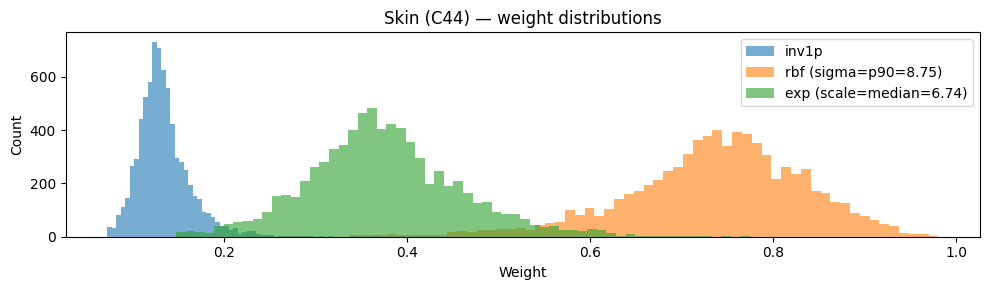

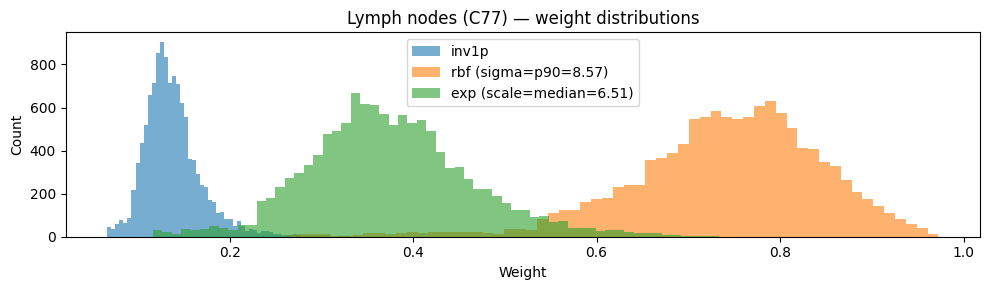

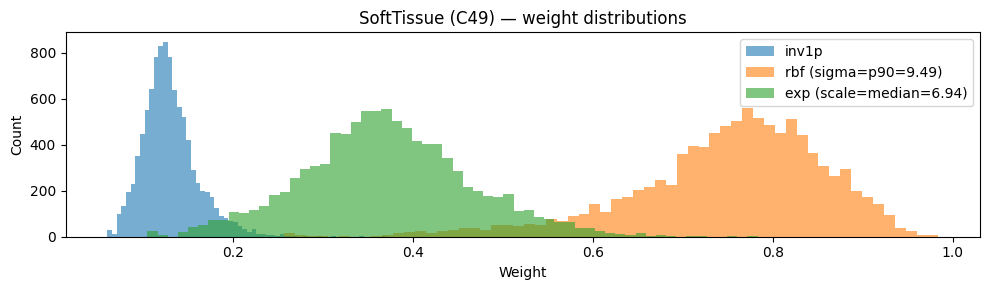

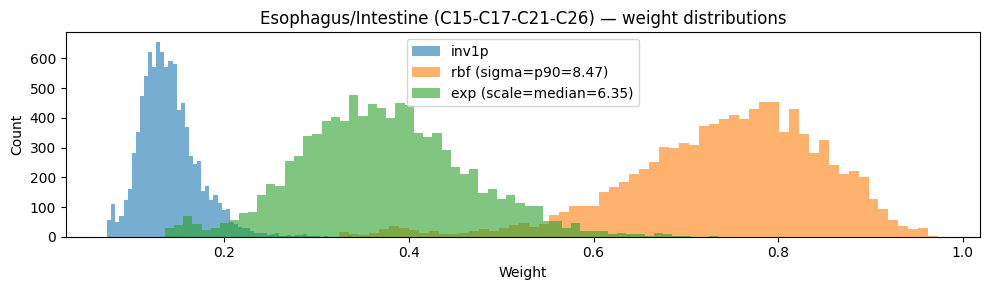

In [30]:
# Visualization of the wheight distribution
#visualization of the 4 first groups 


import matplotlib.pyplot as plt

groups_show = weights_df["cancer_group"].head(4).tolist()

for cancer_group in groups_show:
    row_w     = weights_df[weights_df["cancer_group"] == cancer_group].iloc[0]
    row_m     = manifest[manifest["cancer_group"] == cancer_group].iloc[0]

    dist_path = KNN_PERGROUP_BEST / row_m["knn_dist_file"]
    dists_df  = pd.read_parquet(dist_path)
    d_cols    = [c for c in dists_df.columns if c != ID_COL]
    d_flat    = dists_df[d_cols].to_numpy(dtype=np.float32).ravel()

    sigma = max(float(row_w["rbf_sigma(p90dist)"]), 1e-6)
    scale = max(float(row_w["exp_scale(meddist)"]), 1e-6)

    w1 = w_inv1p(d_flat)
    w2 = w_rbf(d_flat, sigma=sigma)
    w3 = w_exp(d_flat, scale=scale)

    plt.figure(figsize=(10, 3))
    plt.hist(w1, bins=60, alpha=0.6, label="inv1p")
    plt.hist(w2, bins=60, alpha=0.6,
             label=f"rbf (sigma=p90={sigma:.2f})")
    plt.hist(w3, bins=60, alpha=0.6,
             label=f"exp (scale=median={scale:.2f})")
    plt.title(f"{cancer_group} — weight distributions")
    plt.xlabel("Weight")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [31]:
# ── Choice of the best transformation for each group ─────────────────────────────────────

def pick_best_weight_fn(row):
    spreads = {
        "inv1p": row["inv1p_spread(p90-p10)"],
        "rbf":   row["rbf_spread(p90-p10)"],
        "exp":   row["exp_spread(p90-p10)"],
    }
    return max(spreads, key=spreads.get)

weights_df["best_weight_fn"] = weights_df.apply(pick_best_weight_fn, axis=1)

print("Best transformation by cancer_group :")
print(weights_df[[
    "cancer_group",
    "best_weight_fn",
    "inv1p_spread(p90-p10)",
    "rbf_spread(p90-p10)",
    "exp_spread(p90-p10)",
]].to_string(index=False))

print("\nCount by transformation :")
print(weights_df["best_weight_fn"].value_counts().to_string())

Best transformation by cancer_group :
                         cancer_group best_weight_fn  inv1p_spread(p90-p10)  rbf_spread(p90-p10)  exp_spread(p90-p10)
                           Skin (C44)            rbf               0.066830             0.248190             0.210135
                    Lymph nodes (C77)            rbf               0.072116             0.255900             0.220506
                     SoftTissue (C49)            rbf               0.074099             0.268558             0.238659
Esophagus/Intestine (C15-C17-C21-C26)            rbf               0.075455             0.260584             0.227058
              Liver/Biliary (C22-C24)            rbf               0.077337             0.254433             0.218505
            Bone/SoftTissue (C40-C48)            rbf               0.085308             0.289533             0.272427
                         Breast (C50)            rbf               0.091402             0.265820             0.234611
                  

In [32]:
print("pergroup_best existe :", KNN_PERGROUP_BEST.exists())
print("\nFichiers parquet dans pergroup_best :")
for f in sorted(KNN_PERGROUP_BEST.glob("*.parquet")):
    print(f"  {f.name}")

pergroup_best existe : True

Fichiers parquet dans pergroup_best :
  Blood_Lymph_C42_knn_dist_k50_factors20_euclidean.parquet
  Blood_Lymph_C42_knn_idx_k50_factors20_euclidean.parquet
  Bone_SoftTissue_C40-C48_knn_dist_k50_factors20_euclidean.parquet
  Bone_SoftTissue_C40-C48_knn_idx_k50_factors20_euclidean.parquet
  Brain_C71_knn_dist_k50_factors20_euclidean.parquet
  Brain_C71_knn_idx_k50_factors20_euclidean.parquet
  Breast_C50_knn_dist_k50_factors20_euclidean.parquet
  Breast_C50_knn_idx_k50_factors20_euclidean.parquet
  C16_knn_dist_k50_factors20_euclidean.parquet
  C16_knn_idx_k50_factors20_euclidean.parquet
  C25_knn_dist_k50_factors20_euclidean.parquet
  C25_knn_idx_k50_factors20_euclidean.parquet
  Colorectal_C18-C20_knn_dist_k50_factors20_euclidean.parquet
  Colorectal_C18-C20_knn_idx_k50_factors20_euclidean.parquet
  Esophagus_Intestine_C15-C17-C21-C26_knn_dist_k50_factors20_euclidean.parquet
  Esophagus_Intestine_C15-C17-C21-C26_knn_idx_k50_factors20_euclidean.parquet
  Eye

In [33]:
# ── Build the graphs, with the optimal transofrmation per group 

def build_weighted_graph(ids, neigh_ids, neigh_dists,
                         weight_fn, id_col=ID_COL):
    """
        Constructs a weighted undirected igraph from a kNN
        weight_fn: distance → weight transformation function
        chosen specifically for this cancer_group
    """
    n         = len(ids)
    weights   = weight_fn(neigh_dists)
    id_to_idx = {bid: i for i, bid in enumerate(ids)}

    src_list, dst_list, w_list = [], [], []

    for i in range(n):
        for j in range(neigh_ids.shape[1]):
            nid = str(neigh_ids[i, j])
            ni  = id_to_idx.get(nid, -1)
            if ni < 0:
                continue
            src_list.append(i)
            dst_list.append(ni)
            w_list.append(float(weights[i, j]))

    # Directed graph then become undirected  
    g = ig.Graph(n=n, directed=True)
    g.vs[id_col] = ids.tolist()
    g.add_edges(list(zip(src_list, dst_list)))
    g.es["weight"] = w_list
    g = g.as_undirected(combine_edges={"weight": "max"})
    g = g.simplify(combine_edges={"weight": "max"})

    return g


graphs      = {}
graph_infos = []

for _, row_m in manifest.iterrows():
    cancer_group = row_m["cancer_group"]

    # Retrieve the optimal parameters and transformation 
    # pour CE groupe spécifiquement
    row_w   = weights_df[weights_df["cancer_group"] == cancer_group].iloc[0]
    sigma   = max(float(row_w["rbf_sigma(p90dist)"]), 1e-6)
    scale   = max(float(row_w["exp_scale(meddist)"]), 1e-6)
    best_fn = row_w["best_weight_fn"]

    # Load kNN
    ids_df   = pd.read_parquet(KNN_PERGROUP_BEST / row_m["knn_idx_file"])
    dists_df = pd.read_parquet(KNN_PERGROUP_BEST / row_m["knn_dist_file"])

    ids         = ids_df[ID_COL].astype(str).to_numpy()
    nn_cols     = [c for c in ids_df.columns   if c != ID_COL]
    d_cols      = [c for c in dists_df.columns if c != ID_COL]
    neigh_ids   = ids_df[nn_cols].to_numpy(dtype=object)
    neigh_dists = dists_df[d_cols].to_numpy(dtype=np.float32)

    if best_fn == "inv1p":
        wfn = w_inv1p
    elif best_fn == "rbf":
        wfn = lambda d, s=sigma: w_rbf(d, sigma=s)
    else:
        wfn = lambda d, sc=scale: w_exp(d, scale=sc)

    g = build_weighted_graph(ids, neigh_ids, neigh_dists, weight_fn=wfn)
    graphs[cancer_group] = g

    graph_infos.append({
        "cancer_group": cancer_group,
        "n_vertices":   int(g.vcount()),
        "n_edges":      int(g.ecount()),
        "weight_fn":    best_fn,
        "rbf_sigma":    round(sigma, 4),
        "exp_scale":    round(scale, 4),
        "w_min":        round(float(np.min(g.es["weight"])), 4),
        "w_median":     round(float(np.median(g.es["weight"])), 4),
        "w_max":        round(float(np.max(g.es["weight"])), 4),
    })

    print(f"[{cancer_group}] "
          f"v={g.vcount():,}  "
          f"e={g.ecount():,}  "
          f"fn={best_fn}")

graph_infos_df = pd.DataFrame(graph_infos)
print(f"\nBuilt graphs: {len(graphs)}")
print(graph_infos_df[["cancer_group", "n_vertices",
                       "n_edges", "weight_fn"]].to_string(index=False))

[Blood/Lymph (C42)] v=107  e=2,971  fn=exp
[Bone/SoftTissue (C40-C48)] v=113  e=3,915  fn=rbf
[Brain (C71)] v=737  e=26,223  fn=exp
[Breast (C50)] v=969  e=33,441  fn=rbf
[C16] v=406  e=14,670  fn=rbf
[C25] v=165  e=5,809  fn=exp
[Colorectal (C18-C20)] v=565  e=20,436  fn=rbf
[Esophagus/Intestine (C15-C17-C21-C26)] v=193  e=6,668  fn=rbf
[Eye/CNS (C69-C72)] v=85  e=2,415  fn=exp
[Gynecologic (C51-C58)] v=1,135  e=38,991  fn=rbf
[Head & Neck (C00_C14)] v=379  e=13,866  fn=rbf
[Liver/Biliary (C22-C24)] v=398  e=13,355  fn=rbf
[Lung (C30-C39)] v=1,302  e=45,439  fn=rbf
[Lymph nodes (C77)] v=237  e=7,918  fn=rbf
[Male genital (C60-C63)] v=617  e=22,359  fn=exp
[Skin (C44)] v=149  e=4,730  fn=rbf
[SoftTissue (C49)] v=196  e=6,842  fn=rbf
[Thyroid/Endocrine (C73-C75)] v=719  e=25,274  fn=exp
[Urinary (C64-C68)] v=1,110  e=38,584  fn=exp

Built graphs: 19
                         cancer_group  n_vertices  n_edges weight_fn
                    Blood/Lymph (C42)         107     2971       exp
 

### Quality check of the graphs

In [34]:
def sanity_check_graph(g, id_attr=ID_COL, weight_attr="weight"):
    n = int(g.vcount())
    m = int(g.ecount())

    node_ids     = g.vs[id_attr]
    n_unique_ids = len(set(node_ids))
    id_ok        = (n_unique_ids == n)

    n_loops      = sum(g.is_loop())

    w            = np.array(g.es[weight_attr], dtype=float)
    w_min        = float(np.min(w))    if len(w) > 0 else np.nan
    w_med        = float(np.median(w)) if len(w) > 0 else np.nan
    w_max        = float(np.max(w))    if len(w) > 0 else np.nan
    n_nonfinite  = int((~np.isfinite(w)).sum())
    n_nonpos     = int((w <= 0).sum())

    comps        = g.components()
    comp_sizes   = np.array(comps.sizes(), dtype=int)
    n_comps      = int(len(comps))
    giant_size   = int(comp_sizes.max()) if len(comp_sizes) > 0 else 0
    giant_frac   = float(giant_size / n) if n > 0 else 0.0

    issues = []
    if not id_ok:       issues.append(f"duplicate_ids={n - n_unique_ids}")
    if n_loops   > 0:   issues.append(f"self_loops={n_loops}")
    if n_nonfinite > 0: issues.append(f"nonfinite_weights={n_nonfinite}")
    if n_nonpos  > 0:   issues.append(f"nonpos_weights={n_nonpos}")
    if giant_frac < 0.90: issues.append(f"giant_frac={giant_frac:.3f}<0.90")

    return {
        "v":             n,
        "e":             m,
        "id_ok":         bool(id_ok),
        "self_loops":    n_loops,
        "w_min":         round(w_min, 4),
        "w_med":         round(w_med, 4),
        "w_max":         round(w_max, 4),
        "n_nonfinite_w": n_nonfinite,
        "n_nonpos_w":    n_nonpos,
        "n_components":  n_comps,
        "giant_size":    giant_size,
        "giant_frac":    round(giant_frac, 3),
        "issues":        "; ".join(issues) if issues else "",
        "ok":            len(issues) == 0,
    }

qc_rows = []
for cancer_group, g in graphs.items():
    r = sanity_check_graph(g, id_attr=ID_COL, weight_attr="weight")
    r["cancer_group"] = cancer_group
    qc_rows.append(r)

qc_df = (
    pd.DataFrame(qc_rows)
    .sort_values(["ok", "giant_frac"], ascending=[True, True])
    .reset_index(drop=True)
)

print("QC of graphs :")
print(qc_df[[
    "cancer_group", "v", "e",
    "self_loops", "n_nonfinite_w", "n_nonpos_w",
    "n_components", "giant_frac", "ok", "issues"
]].to_string(index=False))

n_ok     = int(qc_df["ok"].sum())
n_issues = int((~qc_df["ok"]).sum())
print(f"\n{n_ok}/{len(qc_df)} graphes OK")
if n_issues > 0:
    print(f"WARNING : {n_issues} graphss with issues :")
    print(qc_df[~qc_df["ok"]][["cancer_group", "issues"]].to_string(index=False))

QC of graphs :
                         cancer_group    v     e  self_loops  n_nonfinite_w  n_nonpos_w  n_components  giant_frac   ok issues
                    Blood/Lymph (C42)  107  2971           0              0           0             1         1.0 True       
            Bone/SoftTissue (C40-C48)  113  3915           0              0           0             1         1.0 True       
                          Brain (C71)  737 26223           0              0           0             1         1.0 True       
                         Breast (C50)  969 33441           0              0           0             1         1.0 True       
                                  C16  406 14670           0              0           0             1         1.0 True       
                                  C25  165  5809           0              0           0             1         1.0 True       
                 Colorectal (C18-C20)  565 20436           0              0           0             1  

### Clusetering : Leiden Algorithm

In [35]:
import leidenalg as la
from sklearn.metrics import adjusted_rand_score

SEEDS            = [0, 1, 2, 3, 4]
MIN_CLUSTER_SIZE = 50      # smaller clusters outliers
MAX_FRAC_IN_SMALL = 0.02   # max 2% of the nodes in small clusters 
MAX_GIANT_FRAC    = 0.95   # the highest cluster should not have more than 95% of the nodes

In [36]:
# ── Fonctions helper — même que tutrice ───────────────────────────

def run_leiden_cpm(g, resolution, seed, weight_attr="weight"):
    """
    Run Leiden CPM on an igraph.
    Returns membership (cluster per node) and statistics.
    """
    part = la.find_partition(
        g,
        la.CPMVertexPartition,
        weights=g.es[weight_attr] if weight_attr in g.es.attributes() else None,
        resolution_parameter=float(resolution),
        seed=int(seed),
    )
    membership = np.asarray(part.membership, dtype=np.int32)
    stats = {
        "n_clusters": int(len(part)),
        "quality":    float(part.quality()),
    }
    return membership, stats


def summarize_cluster_sizes(membership, min_cluster_size=50):
    """
    Calculates statistics on cluster size.
    Useful for detecting resolutions that create
    too many small clusters or a single giant cluster.
    """
    vc    = pd.Series(membership).value_counts()
    sizes = vc.values.astype(int)
    n     = int(sizes.sum())

    small_mask = sizes < min_cluster_size
    return {
        "min_size":                   int(sizes.min()) if len(sizes) else 0,
        "median_size":                float(np.median(sizes)) if len(sizes) else np.nan,
        "max_size":                   int(sizes.max()) if len(sizes) else 0,
        "p10_size":                   float(np.quantile(sizes, 0.10)) if len(sizes) else np.nan,
        "p25_size":                   float(np.quantile(sizes, 0.25)) if len(sizes) else np.nan,
        "n_small_clusters":           int(small_mask.sum()),
        "frac_nodes_in_small_clusters": float(sizes[small_mask].sum() / n) if n > 0 else np.nan,
        "max_cluster_frac":           float(sizes.max() / n) if n > 0 else np.nan,
    }


def pairwise_ari(memberships):
    """
   Calculate the average ARI between all pairs of runs
    at a fixed resolution.
    ARI = 1.0 → all seeds produce exactly the same clusters
    ARI = 0.0 → the clusters are completely different depending on the seed
    We want a high ARI → stable clustering
    """
    if len(memberships) < 2:
        return np.nan
    aris = []
    for i in range(len(memberships)):
        for j in range(i + 1, len(memberships)):
            aris.append(adjusted_rand_score(memberships[i], memberships[j]))
    return float(np.mean(aris)) if aris else np.nan


def make_resolution_grids(r_min=1e-4, r_max=5e-2, n_broad=15, n_fine=12):
    """
    Resolution grid on a logarithmic scale.
    Logarithmic because the resolution effects are multiplicative.
    """
    coarse = np.logspace(np.log10(r_min), np.log10(r_max), n_broad)
    return coarse, n_fine

In [37]:
def scan_root_leiden_cpm(
    cancer_group, g,
    resolution_grid, seed_list,
    min_cluster_size=50,
    max_clusters_frac=0.20,
    fine_grid_points=12,
):
    """
    Broad and fine scan of resolutions for a cancer group.
    Returns:
    - runs_df: one row per (resolution x seed)
    - summary_df: one row per resolution with ARI and aggregated statistics
    """
    n = int(g.vcount())
    resolution_grid = np.asarray(sorted([float(x) for x in resolution_grid]))

    runs       = []
    mem_by_r   = {}

    #  Broad scan 
    for r in resolution_grid:
        r = float(r)
        mem_by_r[r] = []
        for seed in seed_list:
            mem, st = run_leiden_cpm(g, resolution=r, seed=seed)
            mem_by_r[r].append(mem)

            size_stats = summarize_cluster_sizes(mem, min_cluster_size)
            runs.append({
                "cancer_group": cancer_group,
                "resolution":   r,
                "seed":         int(seed),
                "n_clusters":   int(st["n_clusters"]),
                "quality":      float(st["quality"]),
                **size_stats,
                "grid":         "broad",
            })

    runs_df = pd.DataFrame(runs)

    #  Summary broad : on lign per resolution 
    summary = []
    for r, df_r in runs_df.groupby("resolution", sort=True):
        mems = mem_by_r[float(r)]
        ari  = pairwise_ari(mems)

        n_clusters_med = float(df_r["n_clusters"].median())
        quality_med    = float(df_r["quality"].median())
        frac_small_med = float(df_r["frac_nodes_in_small_clusters"].median())
        giant_frac_med = float(df_r["max_cluster_frac"].median())

        summary.append({
            "cancer_group":              cancer_group,
            "resolution":                float(r),
            "ari_mean_pairwise":         ari,
            "n_clusters_median":         n_clusters_med,
            "quality_median":            quality_med,
            "frac_nodes_in_small_clusters_median": frac_small_med,
            "giant_cluster_frac_median": giant_frac_med,
            "too_tiny":  bool(frac_small_med > MAX_FRAC_IN_SMALL),
            "too_giant": bool(giant_frac_med > MAX_GIANT_FRAC),
            "too_many_clusters": bool(n_clusters_med > (max_clusters_frac * n)),
            "grid":      "broad",
        })

    summary_df = pd.DataFrame(summary).sort_values("resolution")

    #  Choose r_star since the broad scan 
    cand = summary_df[
        (summary_df["n_clusters_median"] >= 2) &
        np.isfinite(summary_df["ari_mean_pairwise"]) &
        (~summary_df["too_tiny"]) &
        (~summary_df["too_giant"]) &
        (~summary_df["too_many_clusters"])
    ].copy()

    if len(cand) == 0:
        # No good resolution find so return the broad scan
        return runs_df, summary_df

    cand   = cand.sort_values(["ari_mean_pairwise", "quality_median"],
                              ascending=[False, False])
    r_star = float(cand.iloc[0]["resolution"])

    #  Fine scan around de r_star 
    log_grid = np.log(resolution_grid)
    idx = int(np.argmin(np.abs(log_grid - np.log(r_star))))
    lo  = max(0, idx - 1)
    hi  = min(len(resolution_grid) - 1, idx + 1)

    fine_grid = np.exp(np.linspace(
        np.log(float(resolution_grid[lo])),
        np.log(float(resolution_grid[hi])),
        fine_grid_points
    ))

    fine_runs     = []
    fine_mem_by_r = {}

    for r in fine_grid:
        r = float(r)
        fine_mem_by_r[r] = []
        for seed in seed_list:
            mem, st = run_leiden_cpm(g, resolution=r, seed=seed)
            fine_mem_by_r[r].append(mem)

            size_stats = summarize_cluster_sizes(mem, min_cluster_size)
            fine_runs.append({
                "cancer_group": cancer_group,
                "resolution":   r,
                "seed":         int(seed),
                "n_clusters":   int(st["n_clusters"]),
                "quality":      float(st["quality"]),
                **size_stats,
                "grid":         "fine",
            })

    fine_runs_df = pd.DataFrame(fine_runs)
    runs_df      = pd.concat([runs_df, fine_runs_df], ignore_index=True)

    # Summary fine scan
    fine_summary = []
    for r, df_r in fine_runs_df.groupby("resolution", sort=True):
        mems = fine_mem_by_r[float(r)]
        ari  = pairwise_ari(mems)

        n_clusters_med = float(df_r["n_clusters"].median())
        quality_med    = float(df_r["quality"].median())
        frac_small_med = float(df_r["frac_nodes_in_small_clusters"].median())
        giant_frac_med = float(df_r["max_cluster_frac"].median())

        fine_summary.append({
            "cancer_group":              cancer_group,
            "resolution":                float(r),
            "ari_mean_pairwise":         ari,
            "n_clusters_median":         n_clusters_med,
            "quality_median":            quality_med,
            "frac_nodes_in_small_clusters_median": frac_small_med,
            "giant_cluster_frac_median": giant_frac_med,
            "too_tiny":  bool(frac_small_med > MAX_FRAC_IN_SMALL),
            "too_giant": bool(giant_frac_med > MAX_GIANT_FRAC),
            "too_many_clusters": bool(n_clusters_med > (max_clusters_frac * n)),
            "grid":      "fine",
        })

    summary_df = pd.concat(
        [summary_df, pd.DataFrame(fine_summary)],
        ignore_index=True
    ).sort_values(["grid", "resolution"]).reset_index(drop=True)

    return runs_df, summary_df

In [38]:
def pick_resolution_from_summary(
    summary_df,
    prefer_grid="fine",
    min_ari=0.80,
):
    """
    Selects the optimal resolution from the summary.
    Criteria in order:
    1. At least 2 clusters
    2. Not too many tiny clusters
    3. No giant clusters
    4. ARI >= min_ari (stable between seeds)
    5. Among the candidates: max ARI then max quality
    """
    df = summary_df.copy()

    # Prefer the fine scan if available
    if prefer_grid and "grid" in df.columns:
        df_pref = df[df["grid"] == prefer_grid]
        if len(df_pref) > 0:
            df = df_pref

    df2 = df[df["n_clusters_median"] >= 2].copy()
    if len(df2) == 0:
        df_any = summary_df[summary_df["n_clusters_median"] >= 2]
        if len(df_any) == 0:
            return float(summary_df.sort_values("resolution").iloc[0]["resolution"])
        return float(df_any.sort_values(
            ["ari_mean_pairwise", "quality_median"],
            ascending=[False, False]
        ).iloc[0]["resolution"])

    cand = df2[
        (~df2["too_tiny"]) &
        (~df2["too_giant"]) &
        (~df2.get("too_many_clusters", pd.Series(False, index=df2.index)))
    ].copy()

    if len(cand) == 0:
        cand = df2[~df2["too_giant"]].copy()
    if len(cand) == 0:
        cand = df2.copy()

    # Promote stable resolutions (ARI >= min_ari)
    strong = cand[cand["ari_mean_pairwise"] >= min_ari]
    if len(strong) > 0:
        cand = strong

    return float(
        cand.sort_values(
            ["ari_mean_pairwise", "quality_median"],
            ascending=[False, False]
        ).iloc[0]["resolution"]
    )


def pick_best_seed_at_resolution(g, resolution, seed_list, min_cluster_size=50):
    """
    Given a fixed resolution, it chooses the seed that produces
    the clustering with the fewest small clusters, then the best quality.
    """
    runs  = []
    mems  = {}

    for seed in seed_list:
        mem, st    = run_leiden_cpm(g, resolution=float(resolution), seed=int(seed))
        mems[seed] = mem
        size_stats = summarize_cluster_sizes(mem, min_cluster_size)
        runs.append({
            "seed":       int(seed),
            "n_clusters": st["n_clusters"],
            "quality":    st["quality"],
            **size_stats,
        })

    runs_df = pd.DataFrame(runs)

    # Promote the seeds without small clusters
    strict = runs_df[runs_df["frac_nodes_in_small_clusters"] == 0.0]
    if len(strict) > 0:
        cand   = strict.sort_values("quality", ascending=False)
        reason = "strict_no_small_clusters"
    else:
        cand   = runs_df.sort_values(
            ["frac_nodes_in_small_clusters", "quality"],
            ascending=[True, False]
        )
        reason = "min_small_cluster_mass_then_max_quality"

    best      = cand.iloc[0].to_dict()
    best_seed = int(best["seed"])

    return {
        "best_seed":        best_seed,
        "membership":       mems[best_seed],
        "stats":            {"n_clusters": int(best["n_clusters"]),
                             "quality":    float(best["quality"])},
        "seed_choice_reason": reason,
    }


def mark_tiny_clusters_as_outliers(clusters_df, cluster_col="cluster",
                                   min_cluster_size=50, outlier_label=-1):
    """
    Marks clusters that are too small as outliers (-1).
    A cluster that is too small is not biologically interpretable.
    """
    df  = clusters_df.copy()
    vc  = df[cluster_col].value_counts()
    tiny = set(vc[vc < min_cluster_size].index.tolist())

    df["cluster_raw"] = df[cluster_col]
    df[cluster_col]   = df[cluster_col].where(
        ~df["cluster_raw"].isin(tiny), outlier_label
    )
    return df

In [39]:
# Leiden on all the  cancer_groups ─────────
ALL_GROUPS = sorted(graphs.keys())
n_total    = len(ALL_GROUPS)

all_stats    = []
all_clusters = {}

for i, cancer_group in enumerate(ALL_GROUPS, start=1):
    g = graphs[cancer_group]
    n = int(g.vcount())
    e = int(g.ecount())

    print(f"\n[{i}/{n_total}] {cancer_group} | v={n:,} e={e:,}", flush=True)

    # Broad + fine scan
    resolution_grid, _ = make_resolution_grids(
        r_min=1e-4, r_max=5e-2, n_broad=15, n_fine=12
    )
    runs_df, summary_df = scan_root_leiden_cpm(
        cancer_group=cancer_group,
        g=g,
        resolution_grid=resolution_grid,
        seed_list=SEEDS,
        min_cluster_size=MIN_CLUSTER_SIZE,
        max_clusters_frac=0.20,
        fine_grid_points=12,
    )

    # Choose the optimal resolutiom 
    r_final = pick_resolution_from_summary(
        summary_df, prefer_grid="fine", min_ari=0.80
    )

    # Best seed at this resolution
    pick = pick_best_seed_at_resolution(
        g=g,
        resolution=r_final,
        seed_list=SEEDS,
        min_cluster_size=MIN_CLUSTER_SIZE,
    )

    # Construire le DataFrame de clusters
    ids_grp    = np.array(g.vs[ID_COL], dtype=str)
    clusters_df = pd.DataFrame({
        ID_COL:    ids_grp,
        "cluster": pick["membership"].astype(int),
    })

    # Mark the small cluster as outliers
    clusters_df = mark_tiny_clusters_as_outliers(
        clusters_df,
        cluster_col="cluster",
        min_cluster_size=MIN_CLUSTER_SIZE,
        outlier_label=-1,
    )

    # Stats finales
    vc      = clusters_df["cluster"].value_counts()
    n_out   = int(vc.get(-1, 0))
    n_clust = int((vc.index != -1).sum())

    print(
        f"    r={r_final:.6g} | "
        f"seed={pick['best_seed']} | "
        f"clusters={n_clust} (outliers={n_out}) | "
        f"quality={pick['stats']['quality']:.3f}",
        flush=True
    )

    all_clusters[cancer_group] = clusters_df
    all_stats.append({
        "cancer_group":                    cancer_group,
        "n_vertices":                      n,
        "n_edges":                         e,
        "resolution":                      float(r_final),
        "best_seed":                       int(pick["best_seed"]),
        "seed_choice_reason":              pick["seed_choice_reason"],
        "n_clusters":                      int(pick["stats"]["n_clusters"]),
        "quality":                         float(pick["stats"]["quality"]),
        "n_clusters_final_excl_outliers":  n_clust,
        "n_outliers":                      n_out,
    })

all_stats_df = pd.DataFrame(all_stats).sort_values("cancer_group")
print("\n=== Final Summary ===")
print(all_stats_df[[
    "cancer_group", "n_vertices", "resolution",
    "n_clusters_final_excl_outliers", "n_outliers", "quality"
]].to_string(index=False))


[1/19] Blood/Lymph (C42) | v=107 e=2,971
    r=0.000242978 | seed=0 | clusters=1 (outliers=47) | quality=1959.361

[2/19] Bone/SoftTissue (C40-C48) | v=113 e=3,915
    r=0.0001 | seed=0 | clusters=1 (outliers=0) | quality=5744.513

[3/19] Brain (C71) | v=737 e=26,223
    r=0.000285542 | seed=0 | clusters=2 (outliers=0) | quality=17351.235

[4/19] Breast (C50) | v=969 e=33,441
    r=0.0030881 | seed=0 | clusters=2 (outliers=0) | quality=46571.619

[5/19] C16 | v=406 e=14,670
    r=0.05 | seed=2 | clusters=2 (outliers=1) | quality=13934.442

[6/19] C25 | v=165 e=5,809
    r=0.0320765 | seed=0 | clusters=1 (outliers=43) | quality=3127.180

[7/19] Colorectal (C18-C20) | v=565 e=20,436
    r=0.00565689 | seed=0 | clusters=2 (outliers=0) | quality=29378.699

[8/19] Esophagus/Intestine (C15-C17-C21-C26) | v=193 e=6,668
    r=0.0001 | seed=0 | clusters=1 (outliers=0) | quality=9538.922

[9/19] Eye/CNS (C69-C72) | v=85 e=2,415
    r=0.0001 | seed=0 | clusters=1 (outliers=0) | quality=1790.155


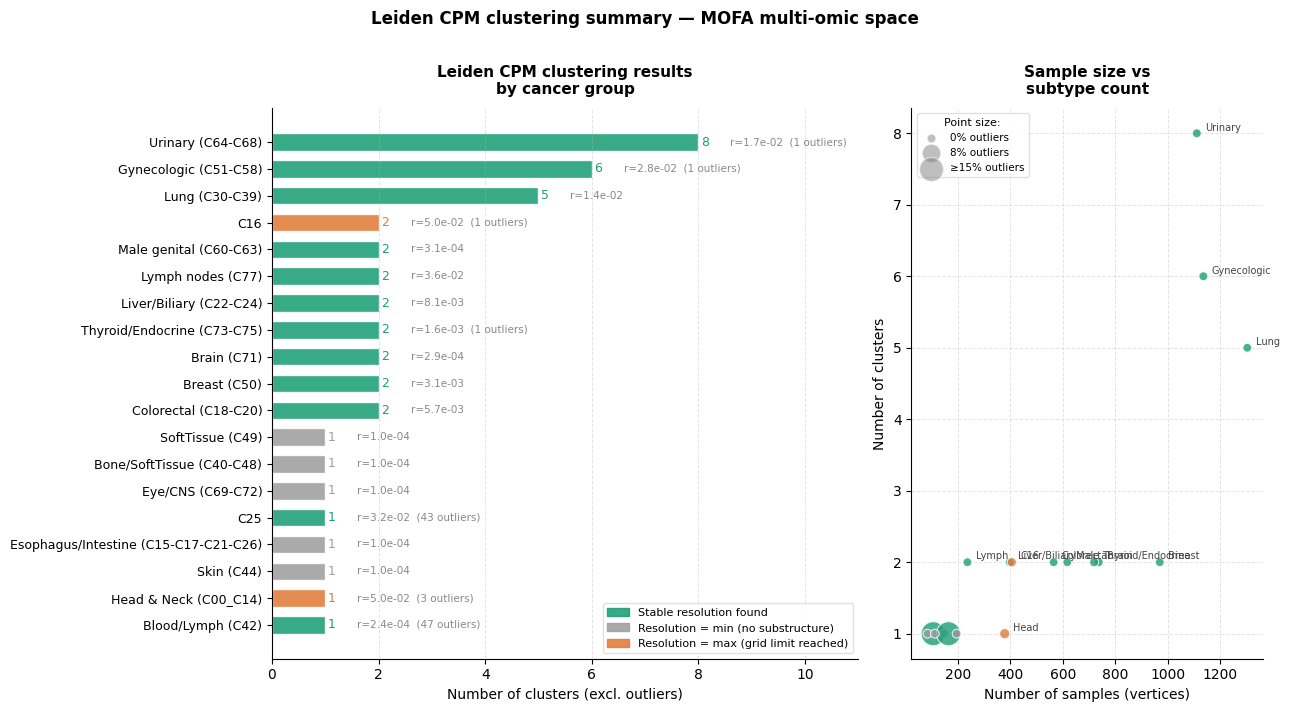


Summary table :
  Cancer group                        n  clusters  outliers   resolution  status
  ────────────────────────────────────────────────────────────────────────────────
  Lung (C30-C39)                   1302         5         0     1.37e-02  ✓
  Gynecologic (C51-C58)            1135         6         1     2.84e-02  ✓
  Urinary (C64-C68)                1110         8         1     1.68e-02  ✓
  Breast (C50)                      969         2         0     3.09e-03  ✓
  Brain (C71)                       737         2         0     2.86e-04  ✓
  Thyroid/Endocrine (C73-C75)       719         2         1     1.62e-03  ✓
  Male genital (C60-C63)            617         2         0     3.10e-04  ✓
  Colorectal (C18-C20)              565         2         0     5.66e-03  ✓
  C16                               406         2         1     5.00e-02  ⚠ grid limit
  Liver/Biliary (C22-C24)           398         2         0     8.13e-03  ✓
  Head & Neck (C00_C14)             379         

In [40]:
# Summary Leiden cluster

R_MIN = 1e-4   # valeur minimale de ta grille
R_MAX = 5e-2   # valeur maximale de ta grille

def plot_leiden_summary(all_stats_df: pd.DataFrame,
                        r_min: float = R_MIN,
                        r_max: float = R_MAX,
                        figsize: tuple = (13, 7)) -> None:
    """
    Résumé visuel horizontal des résultats Leiden.

    Panneau gauche  : barplot du nombre de clusters par groupe
                      (coloré selon le statut de la résolution choisie)
    Panneau droit   : scatter n_vertices vs n_clusters
                      (taille des points = fraction d'outliers)
    """
    df = all_stats_df.sort_values("n_clusters_final_excl_outliers",
                                  ascending=True).reset_index(drop=True)

    # ── Catégories de résolution ──────────────────────────────────────────────
    tol = 1e-6
    def resolution_status(r):
        if abs(r - r_min) < tol:
            return "at_min"       # pas de sous-structure trouvée
        elif abs(r - r_max) < tol:
            return "at_max"       # plafond atteint
        else:
            return "stable"       # zone stable trouvée

    df["res_status"] = df["resolution"].apply(resolution_status)
    df["outlier_frac"] = df["n_outliers"] / df["n_vertices"]

    color_map = {
        "stable":  "#1D9E75",   # vert
        "at_min":  "#9E9E9E",   # gris
        "at_max":  "#E07B39",   # orange
    }
    label_map = {
        "stable": "Stable resolution found",
        "at_min": "Resolution = min (no substructure)",
        "at_max": "Resolution = max (grid limit reached)",
    }

    fig, (ax_left, ax_right) = plt.subplots(
        1, 2, figsize=figsize,
        gridspec_kw={"width_ratios": [2, 1.2]}
    )

    # ── Panneau gauche : barplot horizontal ───────────────────────────────────
    bar_colors = [color_map[s] for s in df["res_status"]]
    bars = ax_left.barh(
        df["cancer_group"],
        df["n_clusters_final_excl_outliers"],
        color=bar_colors, height=0.65, alpha=0.88, edgecolor="white"
    )

    # Annotation : valeur + résolution
    for i, (_, row) in enumerate(df.iterrows()):
        n_cl = int(row["n_clusters_final_excl_outliers"])
        r    = row["resolution"]
        n_out = int(row["n_outliers"])

        # nombre de clusters à droite de la barre
        ax_left.text(n_cl + 0.05, i, f"{n_cl}",
                     va="center", fontsize=9, fontweight="500",
                     color=color_map[row["res_status"]])

        # résolution + outliers en petit
        info = f"r={r:.1e}"
        if n_out > 0:
            info += f"  ({n_out} outliers)"
        ax_left.text(n_cl + 0.6, i, info,
                     va="center", fontsize=7.5, color="#888888")

    ax_left.set_xlabel("Number of clusters (excl. outliers)", fontsize=10)
    ax_left.set_title("Leiden CPM clustering results\nby cancer group",
                      fontsize=11, fontweight="600", pad=10)
    ax_left.spines["top"].set_visible(False)
    ax_left.spines["right"].set_visible(False)
    ax_left.set_xlim(0, df["n_clusters_final_excl_outliers"].max() + 3)
    ax_left.tick_params(axis="y", labelsize=9)
    ax_left.grid(axis="x", linestyle="--", alpha=0.35, linewidth=0.7)

    # Légende résolution
    legend_patches = [
        mpatches.Patch(color=c, label=label_map[k], alpha=0.88)
        for k, c in color_map.items()
    ]
    ax_left.legend(handles=legend_patches, loc="lower right",
                   fontsize=8, framealpha=0.9, edgecolor="#DDDDDD")

    # ── Panneau droit : scatter n_vertices vs n_clusters ─────────────────────
    scatter_colors = [color_map[s] for s in df["res_status"]]

    # taille proportionnelle à la fraction d'outliers (min=40, max=300)
    sizes = 40 + 260 * df["outlier_frac"].clip(0, 0.15) / 0.15

    sc = ax_right.scatter(
        df["n_vertices"],
        df["n_clusters_final_excl_outliers"],
        c=scatter_colors, s=sizes,
        alpha=0.8, edgecolors="white", linewidths=0.8, zorder=3
    )

    # Annotations des groupes notables
    notable = df[
        (df["n_clusters_final_excl_outliers"] >= 2) |
        (df["res_status"] == "at_max")
    ]
    for _, row in notable.iterrows():
        ax_right.annotate(
            row["cancer_group"].split(" ")[0],   # premier mot seulement
            xy=(row["n_vertices"], row["n_clusters_final_excl_outliers"]),
            xytext=(6, 2), textcoords="offset points",
            fontsize=7, color="#444444"
        )

    ax_right.set_xlabel("Number of samples (vertices)", fontsize=10)
    ax_right.set_ylabel("Number of clusters", fontsize=10)
    ax_right.set_title("Sample size vs\nsubtype count",
                       fontsize=11, fontweight="600", pad=10)
    ax_right.spines["top"].set_visible(False)
    ax_right.spines["right"].set_visible(False)
    ax_right.grid(linestyle="--", alpha=0.35, linewidth=0.7)

    # Légende taille des points = outlier fraction
    for frac, label in [(0.0, "0% outliers"), (0.08, "8% outliers"), (0.15, "≥15% outliers")]:
        s = 40 + 260 * frac / 0.15
        ax_right.scatter([], [], s=s, c="gray", alpha=0.5,
                         edgecolors="white", label=label)
    ax_right.legend(fontsize=7.5, loc="upper left",
                    framealpha=0.9, edgecolor="#DDDDDD",
                    title="Point size:", title_fontsize=8)

    plt.suptitle(
        "Leiden CPM clustering summary — MOFA multi-omic space",
        fontsize=12, fontweight="700", y=1.01
    )
    plt.tight_layout()
    plt.show()

    # ── Tableau récapitulatif texte ───────────────────────────────────────────
    print("\nSummary table :")
    print(f"  {'Cancer group':<30} {'n':>6} {'clusters':>9} {'outliers':>9} "
          f"{'resolution':>12}  status")
    print("  " + "─" * 80)
    for _, row in df.sort_values("n_vertices", ascending=False).iterrows():
        status = {"stable": "✓", "at_min": "⚠ no structure", "at_max": "⚠ grid limit"}
        print(f"  {row['cancer_group']:<30} "
              f"{int(row['n_vertices']):>6} "
              f"{int(row['n_clusters_final_excl_outliers']):>9} "
              f"{int(row['n_outliers']):>9} "
              f"{row['resolution']:>12.2e}  "
              f"{status[row['res_status']]}")


# ── Appel ────────────────────────────────────────────────────────────────────
plot_leiden_summary(all_stats_df, r_min=1e-4, r_max=5e-2)

In [41]:
#Save
OUT_BASE     = BASE_DIR / "clustering_leiden_A"
clusters_dir = OUT_BASE / "clusters_by_group"
clusters_dir.mkdir(parents=True, exist_ok=True)

# Et la sauvegarde :
for cancer_group, df in all_clusters.items():
    group_tag = (cancer_group
                 .replace(" ", "_").replace("(", "").replace(")", "")
                 .replace("/", "_"))
    out_path = clusters_dir / f"{group_tag}_clusters_leiden_cpm.parquet"
    df.to_parquet(out_path, index=False)

all_stats_df.to_csv(OUT_BASE / "leiden_manifest_stats.tsv", sep="\t", index=False)

print(f"[saved] clusters → {clusters_dir}")
print(f"[saved] manifest → {OUT_DIR / 'leiden_manifest_stats.tsv'}")

[saved] clusters → /Users/bgadmin/Downloads/multiomics_preproc/clustering_leiden_A/clusters_by_group
[saved] manifest → /Users/bgadmin/Downloads/multiomics_preproc/clustering_leiden/leiden_manifest_stats.tsv
